In [1]:
import math
from iminuit import Minuit
import matplotlib.pyplot as plt

In [4]:
# fixed efficiencies (from simulation)
fixed_e = {"eQx": 0.000157, "eQc": 0.001112}
#fixed correlations (from simulation)
fixed_rho = {
        # "b" correlations 
        ("b", "Q", "Q"): -0.024388875695073087,
        ("b", "Q", "S"): -0.014681408973825416,
        ("b", "Q", "L"): -0.01478104029968752,
        ("b", "Q", "X"): 0.025460339350633854,
        ("b", "Q", "C"): -0.005259540244790473,
        ("b", "S", "S"): -0.03251168991502096,
        ("b", "S", "L"): -0.00866788403752039,
        ("b", "S", "C"): -0.05224735588293217,
        ("b", "S", "X"): 0.008141486420410349,
        ("b", "L", "L"): -0.026745888870009615,
        ("b", "L", "C"): 0.0006933836185840647,
        ("b", "L", "X"): -0.01720332891996601,
        ("b", "X", "X"): -0.28228189903976975,
        ("b", "X", "C"): -0.05534734736922631,
        ("b", "C", "C"): 0.12249521565709798,
        # "c" correlations
        ("c", "Q", "Q"): 0.00,
        ("c", "Q", "S"): 0.02200888192267514,
        ("c", "Q", "L"): 0.32383861595229413,
        ("c", "Q", "X"): -0.3358432846494449,
        ("c", "Q", "C"): -0.45597690809339875,
        ("c", "S", "S"): 0.313513688016529,
        ("c", "S", "L"): -0.1254869804021751,
        ("c", "S", "C"): -0.2428853456079546,
        ("c", "S", "X"): -0.32369223565269056,
        ("c", "L", "L"): -0.05286185806617372,
        ("c", "L", "C"): -0.25411230406197116,
        ("c", "L", "X"): -0.23723294295036723,
        ("c", "C", "C"): -0.1873009162087722,
        ("c", "X", "C"): -0.1679674097428946,
        ("c", "X", "X"): -0.20079015675450818,
        # "x" correlations
        ("x", "Q", "Q"): 0.00,
        ("x", "Q", "S"): 0.00,
        ("x", "Q", "L"): 0.00,
        ("x", "Q", "X"): -0.23000067021018822,
        ("x", "Q", "C"): 0.24537710021262704,
        ("x", "S", "S"): 0.00,
        ("x", "S", "L"): 0.9531788662829419,
        ("x", "S", "C"): 0.0729587558995426,
        ("x", "S", "X"): -0.2542038329352746,
        ("x", "L", "L"): 0.42939899111804647,
        ("x", "L", "C"): -0.137618253953539,
        ("x", "L", "X"): -0.21427849550468714,
        ("x", "C", "C"): -0.12831737388122078,
        ("x", "X", "C"): -0.1504458080376524,
        ("x", "X", "X"): -0.12470610714608843,
                }
# measured number of events
'''
eventsNumber = {
        "N_tot": 955206,
        "single": {
            "Q": 21500,
            "S": 7058,
            "L": 7375,
            "X": 145050,
            "C": 17934,
        },
        "double": {
            ("Q", "Q"): 70016,
            ("S", "S"): 2815,
            ("L", "L"): 1326,
            ("X", "X"): 487075,
            ("C", "C"): 5195,
            ("Q", "S"): 27212,
            ("Q", "L"): 17285,
            ("Q", "X"): 38251,
            ("Q", "C"): 4124,
            ("S", "L"): 3938,
            ("S", "X"): 17374,
            ("S", "C"): 2140,
            ("L", "X"): 22920,
            ("L", "C"): 2564,
            ("X", "C"): 33844,
        }
    }
'''
MC_eventsNumber = {
        "N_tot": 930302.541871,
        "single": {
            "Q": 21801.194,
            "S": 12613.351,
            "L": 28194.931,
            "X": 261879.585,
            "C": 57496.439,
        },
        "double": {
            ("Q", "Q"): 33734.325,
            ("S", "S"): 8315.601,
            ("L", "L"): 9134.142,
            ("X", "X"): 206210.625,
            ("C", "C"): 18177.155,
            ("Q", "S"): 33908.449,
            ("Q", "L"): 32912.529,
            ("Q", "X"): 5087.000,
            ("Q", "C"): 6445.811,
            ("S", "L"): 16733.723,
            ("S", "X"): 3347.395,
            ("S", "C"): 3947.876,
            ("L", "X"): 14502.668,
            ("L", "C"): 10935.585,
            ("X", "C"): 30154.223,
        }
    }

# prefit events number
eventsNumber = {
        "N_tot": 930302.541871,
        "single": {
            "Q": 21714.610532,
            "S": 12991.265438,
            "L": 32158.109218,
            "X": 308226.877642,
            "C": 70957.202437,
        },
        "double": {
            ("Q", "Q"): 33508.585750,
            ("S", "S"): 8255.311334,
            ("L", "L"): 9399.072454,
            ("X", "X"): 241840.787700,
            ("C", "C"): 22731.312489,
            ("Q", "S"): 33684.001344,
            ("Q", "L"): 32698.110101,
            ("Q", "X"): 5076.037709,
            ("Q", "C"): 6420.480716,
            ("S", "L"): 16692.146034,
            ("S", "X"): 3516.914616,
            ("S", "C"): 4162.407914,
            ("L", "X"): 16854.615284,
            ("L", "C"): 12896.324161,
            ("X", "C"): 36538.984298,
        }
    }
# Rc
Rc = 0.172

class RbFit:
    def __init__(self, events, fixed_e, fixed_rho, Rc=0.172):
        self.events = events
        self.fixed_e = fixed_e
        self.fixed_rho = fixed_rho
        self.Rc = Rc
        self.tags = ["Q", "S", "L", "X", "C"]
        self.tag_order = {t: i for i, t in enumerate(self.tags)}

    def predict(self, Rb, eQb, eSx, eSc, eSb,
                eLx, eLc, eLb, eCx, eCc, eCb,
                eXx, eXc, eXb):

        epsilon_b = {"Q": eQb, "S": eSb, "L": eLb, "C": eCb, "X": eXb}
        epsilon_c = {"Q": self.fixed_e["eQc"], "S": eSc, "L": eLc, "C": eCc, "X": eXc}
        epsilon_x = {"Q": self.fixed_e["eQx"], "S": eSx, "L": eLx, "C": eCx, "X": eXx}

        N_tot = self.events["N_tot"]
        
        # compute fsI
        fs = {}
        for I in self.tags:
            fs[I] = (Rb*epsilon_b[I]+Rc*epsilon_c[I]+(1-Rb-Rc)*epsilon_x[I])

        # compute fdIJ
        fd = {}
        pred_double = {}
        for i, I in enumerate(self.tags):
            for J in self.tags[i:]:
                coeff = 1.0 if J == I else 2.0
                fd[(I, J)] = (
                    Rb*epsilon_b[I]*epsilon_b[J]*(1+self.fixed_rho[("b", I, J)])+
                    Rc*epsilon_c[I]*epsilon_c[J]*(1+self.fixed_rho[("c", I, J)])+
                    (1-Rb-Rc)*epsilon_x[I]*epsilon_x[J]*(1+self.fixed_rho[("x", I, J)])
                )
                pred_double[(I, J)] = N_tot * fd[(I, J)]*coeff
                #N_d + [pred_double[(I, J)]]
                #print(f"predict double {I}{J}", pred_double[(I, J)])

        # compute singly tagged
        '''
        pred_single = {}
        for I in self.tags:
            sum_fd_singly = 0.0
            for J in self.tags:
                key = (I, J) if self.tag_order[I] <= self.tag_order[J] else (J, I)
                #print(f"{I}{J}")
                coeff = 1.0 if J == I else 2.0
                sum_fd_singly += fd[key]*coeff
            pred_single[I] = N_tot * (2.0 * fs[I] - sum_fd_singly)
            #print(f"predict single {I}", pred_single[I])
        '''
        pred_single = {}
        for I in self.tags:
            sum_fd_singly = 0.0
            for J in self.tags:
                key = (I, J) if self.tag_order[I] <= self.tag_order[J] else (J, I)
                sum_fd_singly += 2.0 * fd[key]
            pred_single[I] = N_tot * (2.0 * fs[I] - sum_fd_singly)
        return {"single": pred_single, "double": pred_double}
    
    def nll(self, Rb, eQb, eSx, eSc, eSb,
            eLx, eLc, eLb, eCx, eCc, eCb,
            eXx, eXc, eXb):

        pred = self.predict(Rb, eQb, eSx, eSc, eSb,
                            eLx, eLc, eLb, eCx, eCc, eCb,
                            eXx, eXc, eXb)

        total = 0.0

        for I, obs in self.events["single"].items():
            mu = pred["single"][I]
            if mu <= 0:
                return 1e30
            # NEW: Numerically stable Poisson NLL
            if obs > 0:
                total += mu - obs + obs * math.log(obs / mu)
                #total += mu - obs * math.log(mu)
            else:
                total += mu

        for IJ, obs in self.events["double"].items():
            mu = pred["double"][IJ]
            if mu <= 0:
                return 1e30
            # NEW: Numerically stable Poisson NLL
            if obs > 0:
                total += mu - obs + obs * math.log(obs / mu)
                #total += mu - obs * math.log(mu)
            else:
                total += mu

        return total


In [5]:
fit = RbFit(eventsNumber, fixed_e, fixed_rho, Rc=0.172)
'''
m = Minuit(
    fit.nll,
    Rb=0.2158,
    eQb=0.19, eSb=0.18, eLb=0.04, eCb=0.026, eXb=0.002,
    eSc=0.01, eLc=0.01, eCc=0.2, eXc=0.04,
    eSx=0.002, eLx=0.002, eCx=0.08, eXx=0.1,
)
'''
m = Minuit(
    fit.nll,
    Rb=0.2158,
    eQb=0.413619, eSb=0.205819, eLb=0.199547, eCb=0.038347, eXb=0.029007,
    eSc=0.011247, eLc=0.095508, eCc=0.412001, eXc=0.173065,
    eSx=0.001157, eLx=0.017041, eCx=0.025627, eXx=0.690799,
)
m.errordef = Minuit.LIKELIHOOD
#m.limits["Rb"] = (0.1, 0.3)

#for p in m.parameters:
#    if p != "Rb":
#        m.limits[p] = (0.0, 1)

In [6]:
m.migrad()
m.hesse()
m.minos

print("=== Best-fit values ===")
for p in m.parameters:
    print(f"{p:>5s} = {m.values[p]:.6g} +/- {m.errors[p]:.6g}")
print()

print("valid minimum:", m.valid)
print("fval (NLL) =", m.fval)

# optional Pearson-style diagnostic
pred = fit.predict(
    m.values["Rb"],
    m.values["eQb"], m.values["eSx"], m.values["eSc"], m.values["eSb"],
    m.values["eLx"], m.values["eLc"], m.values["eLb"], m.values["eCx"],
    m.values["eCc"], m.values["eCb"], m.values["eXx"], m.values["eXc"],
    m.values["eXb"]
)

chi2 = 0.0
nobs = 0

for I, obs in eventsNumber["single"].items():
    exp = pred["single"][I]
    chi2 += (obs - exp) ** 2 / exp
    nobs += 1

for IJ, obs in eventsNumber["double"].items():
    exp = pred["double"][IJ]
    chi2 += (obs - exp) ** 2 / exp
    nobs += 1

ndof = nobs - m.nfit
print("Pearson chi2 =", chi2)
print("ndof =", ndof)
print("chi2/ndof =", chi2 / ndof if ndof > 0 else float("nan"))
print()

if m.valid:
    m.minos()
    print("=== Minos errors ===")
    for p in m.parameters:
        if p in m.merrors:
            print(f"{p:>4s} : {m.merrors[p].lower:.6g} / +{m.merrors[p].upper:.6g}")
else:
    print("Minimum is not valid, so minos() was skipped.")

=== Best-fit values ===
   Rb = 0.2158 +/- 0.000595212
  eQb = 0.413619 +/- 0.00112328
  eSx = 0.001157 +/- 0.000127948
  eSc = 0.011247 +/- 0.000702972
  eSb = 0.205819 +/- 0.000709632
  eLx = 0.017041 +/- 0.000229429
  eLc = 0.095508 +/- 0.00111444
  eLb = 0.199547 +/- 0.000734938
  eCx = 0.025627 +/- 0.000327879
  eCc = 0.412001 +/- 0.00139106
  eCb = 0.038347 +/- 0.000467205
  eXx = 0.690799 +/- 0.000715478
  eXc = 0.173065 +/- 0.00163793
  eXb = 0.029007 +/- 0.000400387

valid minimum: True
fval (NLL) = -2.5923247273923774e-11
Pearson chi2 = 1.6153756176258626e-16
ndof = 6
chi2/ndof = 2.6922926960431043e-17

=== Minos errors ===
  Rb : -0.000593328 / +0.000594752
 eQb : -0.00112129 / +0.00112203
 eSx : -0.000127903 / +0.000128438
 eSc : -0.000697576 / +0.000700143
 eSb : -0.000707092 / +0.000708216
 eLx : -0.000225558 / +0.000226253
 eLc : -0.00109696 / +0.00110078
 eLb : -0.000731911 / +0.000732648
 eCx : -0.000324588 / +0.000324775
 eCc : -0.00139485 / +0.00139612
 eCb : -0.0004

In [8]:
# fixed efficiencies + eQx detector up uncertainties 
fixed_detector_eQx_up = {"eQx": 0.000157+0.00005, "eQc": 0.001112}
# fixed efficiencies + eQx detector down uncertainties
fixed_detector_eQx_down = {"eQx": 0.000157-0.00005, "eQc": 0.001112}

# fixed efficiencies + eQc detector up uncertainties 
fixed_detector_eQc_up = {"eQx": 0.000157, "eQc": 0.001112+0.00009}
# fixed efficiencies + eQc detector down uncertainties
fixed_detector_eQc_down = {"eQx": 0.000157, "eQc": 0.001112-0.00009}

In [9]:
# fixed efficiencies + eQx physical up uncertainties 
fixed_physical_eQx_up = {"eQx": 0.000157+0.0001, "eQc": 0.001112}
# fixed efficiencies + eQx physical down uncertainties
fixed_physical_eQx_down = {"eQx": 0.000157-0.0001, "eQc": 0.001112}

# fixed efficiencies + eQc physical up uncertainties 
fixed_physical_eQc_up = {"eQx": 0.000157, "eQc": 0.001112+0.00027}
# fixed efficiencies + eQc physical down uncertainties
fixed_physical_eQc_down = {"eQx": 0.000157, "eQc": 0.001112-0.00027}

In [10]:
# fixed efficiencies + eQx statistical up uncertainties 
fixed_statistical_eQx_up = {"eQx": 0.000157+0.000016, "eQc": 0.001112}
# fixed efficiencies + eQx statistical down uncertainties
fixed_statistical_eQx_down = {"eQx": 0.000157-0.000016, "eQc": 0.001112}

# fixed efficiencies + eQc statistical up uncertainties 
fixed_statistical_eQc_up = {"eQx": 0.000157, "eQc": 0.001112+0.000084}
# fixed efficiencies + eQc statistical down uncertainties
fixed_statistical_eQc_down = {"eQx": 0.000157, "eQc": 0.001112-0.000084}

In [11]:
#fixed correlations + stat up uncertainties
fixed_rho_up = {
        # "b" correlations 
        ("b", "Q", "Q"): -0.024388875695073087 + 0.004089,
        ("b", "Q", "S"): -0.014681408973825416 + 0.004775,
        ("b", "Q", "L"): -0.01478104029968752 + 0.005562,
        ("b", "Q", "X"): 0.025460339350633854 + 0.014258,
        ("b", "Q", "C"): -0.005259540244790473 + 0.012114,
        ("b", "S", "S"): -0.03251168991502096 + 0.011281,
        ("b", "S", "L"): -0.00866788403752039 + 0.007670,
        ("b", "S", "C"): -0.05224735588293217 + 0.019680,
        ("b", "S", "X"): 0.008141486420410349 + 0.021511,
        ("b", "L", "L"): -0.026745888870009615 + 0.011336,
        ("b", "L", "C"): 0.0006933836185840647 + 0.019678,
        ("b", "L", "X"): -0.01720332891996601 + 0.023693,
        ("b", "X", "X"): -0.28228189903976975 + 0.083534,
        ("b", "X", "C"): -0.05534734736922631 + 0.054066,
        ("b", "C", "C"): 0.12249521565709798 + 0.076558,

        # "c" correlations
        ("c", "Q", "Q"): 0.00,
        ("c", "Q", "S"): 0.02200888192267514,
        ("c", "Q", "L"): 0.32383861595229413,
        ("c", "Q", "X"): -0.3358432846494449,
        ("c", "Q", "C"): -0.45597690809339875 + 0.079547,
        ("c", "S", "S"): 0.313513688016529,
        ("c", "S", "L"): -0.1254869804021751 + 0.068654,
        ("c", "S", "C"): -0.2428853456079546 + 0.027022,
        ("c", "S", "X"): -0.32369223565269056 + 0.044499,
        ("c", "L", "L"): -0.05286185806617372 + 0.032609,
        ("c", "L", "C"): -0.25411230406197116 + 0.008630,
        ("c", "L", "X"): -0.23723294295036723 + 0.015532,
        ("c", "C", "C"): -0.1873009162087722 + 0.005350,
        ("c", "X", "C"): -0.1679674097428946 + 0.006444,
        ("c", "X", "X"): -0.20079015675450818 + 0.015792,

        # "x" correlations
        ("x", "Q", "Q"): 0.00,
        ("x", "Q", "S"): 0.00,
        ("x", "Q", "L"): 0.00,
        ("x", "Q", "X"): -0.23000067021018822 + 0.076145,
        ("x", "Q", "C"): 0.24537710021262704,
        ("x", "S", "S"): 0.00,
        ("x", "S", "L"): 0.9531788662829419,
        ("x", "S", "C"): 0.0729587558995426,
        ("x", "S", "X"): -0.2542038329352746 + 0.028287,
        ("x", "L", "L"): 0.42939899111804647,
        ("x", "L", "C"): -0.137618253953539 + 0.056360,
        ("x", "L", "X"): -0.21427849550468714 + 0.007508,
        ("x", "C", "C"): -0.12831737388122078 + 0.064940,
        ("x", "X", "C"): -0.1504458080376524 + 0.005893,
        ("x", "X", "X"): -0.12470610714608843 + 0.000812,
}

#fixed correlations + stat down uncertainties
fixed_rho_down = {
        # "b" correlations 
        ("b", "Q", "Q"): -0.024388875695073087 - 0.004089,
        ("b", "Q", "S"): -0.014681408973825416 - 0.004775,
        ("b", "Q", "L"): -0.01478104029968752 - 0.005562,
        ("b", "Q", "X"): 0.025460339350633854 - 0.014258,
        ("b", "Q", "C"): -0.005259540244790473 - 0.012114,
        ("b", "S", "S"): -0.03251168991502096 - 0.011281,
        ("b", "S", "L"): -0.00866788403752039 - 0.007670,
        ("b", "S", "C"): -0.05224735588293217 - 0.019680,
        ("b", "S", "X"): 0.008141486420410349 - 0.021511,
        ("b", "L", "L"): -0.026745888870009615 - 0.011336,
        ("b", "L", "C"): 0.0006933836185840647 - 0.019678,
        ("b", "L", "X"): -0.01720332891996601 - 0.023693,
        ("b", "X", "X"): -0.28228189903976975 - 0.083534,
        ("b", "X", "C"): -0.05534734736922631 - 0.054066,
        ("b", "C", "C"): 0.12249521565709798 - 0.076558,

        # "c" correlations
        ("c", "Q", "Q"): 0.00,
        ("c", "Q", "S"): 0.02200888192267514,
        ("c", "Q", "L"): 0.32383861595229413,
        ("c", "Q", "X"): -0.3358432846494449,
        ("c", "Q", "C"): -0.45597690809339875 - 0.079547,
        ("c", "S", "S"): 0.313513688016529,
        ("c", "S", "L"): -0.1254869804021751 - 0.068654,
        ("c", "S", "C"): -0.2428853456079546 - 0.027022,
        ("c", "S", "X"): -0.32369223565269056 - 0.044499,
        ("c", "L", "L"): -0.05286185806617372 - 0.032609,
        ("c", "L", "C"): -0.25411230406197116 - 0.008630,
        ("c", "L", "X"): -0.23723294295036723 - 0.015532,
        ("c", "C", "C"): -0.1873009162087722 - 0.005350,
        ("c", "X", "C"): -0.1679674097428946 - 0.006444,
        ("c", "X", "X"): -0.20079015675450818 - 0.015792,

        # "x" correlations
        ("x", "Q", "Q"): 0.00,
        ("x", "Q", "S"): 0.00,
        ("x", "Q", "L"): 0.00,
        ("x", "Q", "X"): -0.23000067021018822 - 0.076145,
        ("x", "Q", "C"): 0.24537710021262704,
        ("x", "S", "S"): 0.00,
        ("x", "S", "L"): 0.9531788662829419,
        ("x", "S", "C"): 0.0729587558995426,
        ("x", "S", "X"): -0.2542038329352746 - 0.028287,
        ("x", "L", "L"): 0.42939899111804647,
        ("x", "L", "C"): -0.137618253953539 - 0.056360,
        ("x", "L", "X"): -0.21427849550468714 - 0.007508,
        ("x", "C", "C"): -0.12831737388122078 - 0.064940,
        ("x", "X", "C"): -0.1504458080376524 - 0.005893,
        ("x", "X", "X"): -0.12470610714608843 - 0.000812,
}

In [12]:
def rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, tag, direction):
    if tag not in fixed_rho:
        raise KeyError(f"{tag} not found in base_rho")
    if tag not in fixed_rho_up or tag not in fixed_rho_down:
        raise KeyError(f"{tag} not found in rho_up / rho_down")
    new_rho = fixed_rho.copy()
    
    #replace the rho value with the corresponding tags in fixed_rho
    if direction == "up":
        new_rho[tag] = fixed_rho_up[tag]
    elif direction == "down":
        new_rho[tag] = fixed_rho_down[tag]
    return new_rho

In [13]:
import math
import pandas as pd
from iminuit import Minuit

def run_fit(label, fit_obj, do_minos=True):
    m = Minuit(
        fit_obj.nll,
    Rb=0.2158,
    eQb=0.413619, eSb=0.205819, eLb=0.199547, eCb=0.038347, eXb=0.029007,
    eSc=0.011247, eLc=0.095508, eCc=0.412001, eXc=0.173065,
    eSx=0.001157, eLx=0.017041, eCx=0.025627, eXx=0.690799,
    )

    m.errordef = Minuit.LIKELIHOOD
    m.limits["Rb"] = (0.1, 0.3)
    for p in m.parameters:
        if p != "Rb":
            m.limits[p] = (0.0, 1)

    m.migrad()
    m.hesse()
    m.minos()

    pred = fit_obj.predict(
        m.values["Rb"],
        m.values["eQb"], m.values["eSx"], m.values["eSc"], m.values["eSb"],
        m.values["eLx"], m.values["eLc"], m.values["eLb"], m.values["eCx"],
        m.values["eCc"], m.values["eCb"], m.values["eXx"], m.values["eXc"],
        m.values["eXb"]
    )

    #pearson = 0.0
    #nobs = 0
    #for I, obs in fit_obj.events["single"].items():
    #    mu = pred["single"][I]
    #    pearson += (obs - mu) ** 2 / mu
    #    nobs += 1
    #for IJ, obs in fit_obj.events["double"].items():
    #    mu = pred["double"][IJ]
    #    pearson += (obs - mu) ** 2 / mu
    #    nobs += 1

    #ndof = nobs - m.nfit

    out = {
        "variation": label,
        "Rb": m.values["Rb"],
        "Rb_err": m.errors["Rb"],
        "NLL": m.fval,
        #"pearson_chi2": pearson,
        #"ndof": ndof,
        #"chi2_ndof": pearson / ndof if ndof > 0 else float("nan"),
        "valid": m.valid,
        "edm": m.fmin.edm,
        "at_limit": m.fmin.has_parameters_at_limit,
        "minuit": m,
    }

    if "Rb" in m.merrors:
        out["Rb_minos_down"] = m.merrors["Rb"].lower
        out["Rb_minos_up"] = m.merrors["Rb"].upper
    else:
        out["Rb_minos_down"] = float("nan")
        out["Rb_minos_up"] = float("nan")

    return out

In [19]:
# b correlations
rho_bQQ_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "Q", "Q"), "up")
rho_bQQ_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "Q", "Q"), "down")

rho_bQS_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "Q", "S"), "up")
rho_bQS_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "Q", "S"), "down")

rho_bQL_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "Q", "L"), "up")
rho_bQL_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "Q", "L"), "down")

rho_bQX_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "Q", "X"), "up")
rho_bQX_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "Q", "X"), "down")

rho_bQC_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "Q", "C"), "up")
rho_bQC_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "Q", "C"), "down")

rho_bSS_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "S", "S"), "up")
rho_bSS_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "S", "S"), "down")

rho_bSL_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "S", "L"), "up")
rho_bSL_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "S", "L"), "down")

rho_bSC_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "S", "C"), "up")
rho_bSC_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "S", "C"), "down")

rho_bSX_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "S", "X"), "up")
rho_bSX_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "S", "X"), "down")

rho_bLL_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "L", "L"), "up")
rho_bLL_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "L", "L"), "down")

rho_bLC_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "L", "C"), "up")
rho_bLC_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "L", "C"), "down")

rho_bLX_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "L", "X"), "up")
rho_bLX_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "L", "X"), "down")

rho_bXX_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "X", "X"), "up")
rho_bXX_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "X", "X"), "down")

rho_bXC_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "X", "C"), "up")
rho_bXC_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "X", "C"), "down")

rho_bCC_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "C", "C"), "up")
rho_bCC_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("b", "C", "C"), "down")


# c correlations
rho_cQQ_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "Q", "Q"), "up")
rho_cQQ_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "Q", "Q"), "down")

rho_cQS_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "Q", "S"), "up")
rho_cQS_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "Q", "S"), "down")

rho_cQL_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "Q", "L"), "up")
rho_cQL_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "Q", "L"), "down")

rho_cQX_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "Q", "X"), "up")
rho_cQX_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "Q", "X"), "down")

rho_cQC_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "Q", "C"), "up")
rho_cQC_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "Q", "C"), "down")

rho_cSS_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "S", "S"), "up")
rho_cSS_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "S", "S"), "down")

rho_cSL_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "S", "L"), "up")
rho_cSL_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "S", "L"), "down")

rho_cSC_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "S", "C"), "up")
rho_cSC_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "S", "C"), "down")

rho_cSX_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "S", "X"), "up")
rho_cSX_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "S", "X"), "down")

rho_cLL_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "L", "L"), "up")
rho_cLL_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "L", "L"), "down")

rho_cLC_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "L", "C"), "up")
rho_cLC_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "L", "C"), "down")

rho_cLX_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "L", "X"), "up")
rho_cLX_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "L", "X"), "down")

rho_cCC_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "C", "C"), "up")
rho_cCC_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "C", "C"), "down")

rho_cXC_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "X", "C"), "up")
rho_cXC_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "X", "C"), "down")

rho_cXX_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "X", "X"), "up")
rho_cXX_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("c", "X", "X"), "down")


# x correlations
rho_xQQ_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "Q", "Q"), "up")
rho_xQQ_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "Q", "Q"), "down")

rho_xQS_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "Q", "S"), "up")
rho_xQS_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "Q", "S"), "down")

rho_xQL_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "Q", "L"), "up")
rho_xQL_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "Q", "L"), "down")

rho_xQX_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "Q", "X"), "up")
rho_xQX_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "Q", "X"), "down")

rho_xQC_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "Q", "C"), "up")
rho_xQC_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "Q", "C"), "down")

rho_xSS_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "S", "S"), "up")
rho_xSS_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "S", "S"), "down")

rho_xSL_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "S", "L"), "up")
rho_xSL_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "S", "L"), "down")

rho_xSC_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "S", "C"), "up")
rho_xSC_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "S", "C"), "down")

rho_xSX_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "S", "X"), "up")
rho_xSX_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "S", "X"), "down")

rho_xLL_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "L", "L"), "up")
rho_xLL_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "L", "L"), "down")

rho_xLC_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "L", "C"), "up")
rho_xLC_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "L", "C"), "down")

rho_xLX_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "L", "X"), "up")
rho_xLX_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "L", "X"), "down")

rho_xCC_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "C", "C"), "up")
rho_xCC_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "C", "C"), "down")

rho_xXC_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "X", "C"), "up")
rho_xXC_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "X", "C"), "down")

rho_xXX_up = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "X", "X"), "up")
rho_xXX_down = rho_variation(fixed_rho, fixed_rho_up, fixed_rho_down, ("x", "X", "X"), "down")

In [20]:
fits = [
    ("nominal",       RbFit(eventsNumber, fixed_e,               fixed_rho,      Rc=0.172)),
    ("detector_eQx_up",   RbFit(eventsNumber, fixed_detector_eQx_up,   fixed_rho,      Rc=0.172)),
    ("detector_eQx_down", RbFit(eventsNumber, fixed_detector_eQx_down, fixed_rho,      Rc=0.172)),
    ("detector_eQc_up",   RbFit(eventsNumber, fixed_detector_eQc_up,   fixed_rho,      Rc=0.172)),
    ("detector_eQc_down", RbFit(eventsNumber, fixed_detector_eQc_down, fixed_rho,      Rc=0.172)),
    ("physical_eQx_up",   RbFit(eventsNumber, fixed_physical_eQx_up,   fixed_rho,      Rc=0.172)),
    ("physical_eQx_down", RbFit(eventsNumber, fixed_physical_eQx_down, fixed_rho,      Rc=0.172)),
    ("physical_eQc_up",   RbFit(eventsNumber, fixed_physical_eQc_up,   fixed_rho,      Rc=0.172)),
    ("physical_eQc_down", RbFit(eventsNumber, fixed_physical_eQc_down, fixed_rho,      Rc=0.172)),
    ("statistical_eQx_up",   RbFit(eventsNumber, fixed_statistical_eQx_up, fixed_rho,  Rc=0.172)),
    ("statistical_eQx_down", RbFit(eventsNumber, fixed_statistical_eQx_down, fixed_rho,Rc=0.172)),
    ("statistical_eQc_up",   RbFit(eventsNumber, fixed_statistical_eQc_up, fixed_rho,  Rc=0.172)),
    ("statistical_eQc_down", RbFit(eventsNumber, fixed_statistical_eQc_down, fixed_rho,Rc=0.172)),

        # rho MC statistical uncertainties

    # b correlations
    ("rho_statistical_bQQ_up",   RbFit(eventsNumber, fixed_e, rho_bQQ_up, Rc=0.172)),
    ("rho_statistical_bQQ_down", RbFit(eventsNumber, fixed_e, rho_bQQ_down, Rc=0.172)),

    ("rho_statistical_bQS_up",   RbFit(eventsNumber, fixed_e, rho_bQS_up, Rc=0.172)),
    ("rho_statistical_bQS_down", RbFit(eventsNumber, fixed_e, rho_bQS_down, Rc=0.172)),

    ("rho_statistical_bQL_up",   RbFit(eventsNumber, fixed_e, rho_bQL_up, Rc=0.172)),
    ("rho_statistical_bQL_down", RbFit(eventsNumber, fixed_e, rho_bQL_down, Rc=0.172)),

    ("rho_statistical_bQX_up",   RbFit(eventsNumber, fixed_e, rho_bQX_up, Rc=0.172)),
    ("rho_statistical_bQX_down", RbFit(eventsNumber, fixed_e, rho_bQX_down, Rc=0.172)),

    ("rho_statistical_bQC_up",   RbFit(eventsNumber, fixed_e, rho_bQC_up, Rc=0.172)),
    ("rho_statistical_bQC_down", RbFit(eventsNumber, fixed_e, rho_bQC_down, Rc=0.172)),

    ("rho_statistical_bSS_up",   RbFit(eventsNumber, fixed_e, rho_bSS_up, Rc=0.172)),
    ("rho_statistical_bSS_down", RbFit(eventsNumber, fixed_e, rho_bSS_down, Rc=0.172)),

    ("rho_statistical_bSL_up",   RbFit(eventsNumber, fixed_e, rho_bSL_up, Rc=0.172)),
    ("rho_statistical_bSL_down", RbFit(eventsNumber, fixed_e, rho_bSL_down, Rc=0.172)),

    ("rho_statistical_bSC_up",   RbFit(eventsNumber, fixed_e, rho_bSC_up, Rc=0.172)),
    ("rho_statistical_bSC_down", RbFit(eventsNumber, fixed_e, rho_bSC_down, Rc=0.172)),

    ("rho_statistical_bSX_up",   RbFit(eventsNumber, fixed_e, rho_bSX_up, Rc=0.172)),
    ("rho_statistical_bSX_down", RbFit(eventsNumber, fixed_e, rho_bSX_down, Rc=0.172)),

    ("rho_statistical_bLL_up",   RbFit(eventsNumber, fixed_e, rho_bLL_up, Rc=0.172)),
    ("rho_statistical_bLL_down", RbFit(eventsNumber, fixed_e, rho_bLL_down, Rc=0.172)),

    ("rho_statistical_bLC_up",   RbFit(eventsNumber, fixed_e, rho_bLC_up, Rc=0.172)),
    ("rho_statistical_bLC_down", RbFit(eventsNumber, fixed_e, rho_bLC_down, Rc=0.172)),

    ("rho_statistical_bLX_up",   RbFit(eventsNumber, fixed_e, rho_bLX_up, Rc=0.172)),
    ("rho_statistical_bLX_down", RbFit(eventsNumber, fixed_e, rho_bLX_down, Rc=0.172)),

    ("rho_statistical_bXX_up",   RbFit(eventsNumber, fixed_e, rho_bXX_up, Rc=0.172)),
    ("rho_statistical_bXX_down", RbFit(eventsNumber, fixed_e, rho_bXX_down, Rc=0.172)),

    ("rho_statistical_bXC_up",   RbFit(eventsNumber, fixed_e, rho_bXC_up, Rc=0.172)),
    ("rho_statistical_bXC_down", RbFit(eventsNumber, fixed_e, rho_bXC_down, Rc=0.172)),

    ("rho_statistical_bCC_up",   RbFit(eventsNumber, fixed_e, rho_bCC_up, Rc=0.172)),
    ("rho_statistical_bCC_down", RbFit(eventsNumber, fixed_e, rho_bCC_down, Rc=0.172)),


    # c correlations
    ("rho_statistical_cQQ_up",   RbFit(eventsNumber, fixed_e, rho_cQQ_up, Rc=0.172)),
    ("rho_statistical_cQQ_down", RbFit(eventsNumber, fixed_e, rho_cQQ_down, Rc=0.172)),

    ("rho_statistical_cQS_up",   RbFit(eventsNumber, fixed_e, rho_cQS_up, Rc=0.172)),
    ("rho_statistical_cQS_down", RbFit(eventsNumber, fixed_e, rho_cQS_down, Rc=0.172)),

    ("rho_statistical_cQL_up",   RbFit(eventsNumber, fixed_e, rho_cQL_up, Rc=0.172)),
    ("rho_statistical_cQL_down", RbFit(eventsNumber, fixed_e, rho_cQL_down, Rc=0.172)),

    ("rho_statistical_cQX_up",   RbFit(eventsNumber, fixed_e, rho_cQX_up, Rc=0.172)),
    ("rho_statistical_cQX_down", RbFit(eventsNumber, fixed_e, rho_cQX_down, Rc=0.172)),

    ("rho_statistical_cQC_up",   RbFit(eventsNumber, fixed_e, rho_cQC_up, Rc=0.172)),
    ("rho_statistical_cQC_down", RbFit(eventsNumber, fixed_e, rho_cQC_down, Rc=0.172)),

    ("rho_statistical_cSS_up",   RbFit(eventsNumber, fixed_e, rho_cSS_up, Rc=0.172)),
    ("rho_statistical_cSS_down", RbFit(eventsNumber, fixed_e, rho_cSS_down, Rc=0.172)),

    ("rho_statistical_cSL_up",   RbFit(eventsNumber, fixed_e, rho_cSL_up, Rc=0.172)),
    ("rho_statistical_cSL_down", RbFit(eventsNumber, fixed_e, rho_cSL_down, Rc=0.172)),

    ("rho_statistical_cSC_up",   RbFit(eventsNumber, fixed_e, rho_cSC_up, Rc=0.172)),
    ("rho_statistical_cSC_down", RbFit(eventsNumber, fixed_e, rho_cSC_down, Rc=0.172)),

    ("rho_statistical_cSX_up",   RbFit(eventsNumber, fixed_e, rho_cSX_up, Rc=0.172)),
    ("rho_statistical_cSX_down", RbFit(eventsNumber, fixed_e, rho_cSX_down, Rc=0.172)),

    ("rho_statistical_cLL_up",   RbFit(eventsNumber, fixed_e, rho_cLL_up, Rc=0.172)),
    ("rho_statistical_cLL_down", RbFit(eventsNumber, fixed_e, rho_cLL_down, Rc=0.172)),

    ("rho_statistical_cLC_up",   RbFit(eventsNumber, fixed_e, rho_cLC_up, Rc=0.172)),
    ("rho_statistical_cLC_down", RbFit(eventsNumber, fixed_e, rho_cLC_down, Rc=0.172)),

    ("rho_statistical_cLX_up",   RbFit(eventsNumber, fixed_e, rho_cLX_up, Rc=0.172)),
    ("rho_statistical_cLX_down", RbFit(eventsNumber, fixed_e, rho_cLX_down, Rc=0.172)),

    ("rho_statistical_cCC_up",   RbFit(eventsNumber, fixed_e, rho_cCC_up, Rc=0.172)),
    ("rho_statistical_cCC_down", RbFit(eventsNumber, fixed_e, rho_cCC_down, Rc=0.172)),

    ("rho_statistical_cXC_up",   RbFit(eventsNumber, fixed_e, rho_cXC_up, Rc=0.172)),
    ("rho_statistical_cXC_down", RbFit(eventsNumber, fixed_e, rho_cXC_down, Rc=0.172)),

    ("rho_statistical_cXX_up",   RbFit(eventsNumber, fixed_e, rho_cXX_up, Rc=0.172)),
    ("rho_statistical_cXX_down", RbFit(eventsNumber, fixed_e, rho_cXX_down, Rc=0.172)),


    # x correlations
    ("rho_statistical_xQQ_up",   RbFit(eventsNumber, fixed_e, rho_xQQ_up, Rc=0.172)),
    ("rho_statistical_xQQ_down", RbFit(eventsNumber, fixed_e, rho_xQQ_down, Rc=0.172)),

    ("rho_statistical_xQS_up",   RbFit(eventsNumber, fixed_e, rho_xQS_up, Rc=0.172)),
    ("rho_statistical_xQS_down", RbFit(eventsNumber, fixed_e, rho_xQS_down, Rc=0.172)),

    ("rho_statistical_xQL_up",   RbFit(eventsNumber, fixed_e, rho_xQL_up, Rc=0.172)),
    ("rho_statistical_xQL_down", RbFit(eventsNumber, fixed_e, rho_xQL_down, Rc=0.172)),

    ("rho_statistical_xQX_up",   RbFit(eventsNumber, fixed_e, rho_xQX_up, Rc=0.172)),
    ("rho_statistical_xQX_down", RbFit(eventsNumber, fixed_e, rho_xQX_down, Rc=0.172)),

    ("rho_statistical_xQC_up",   RbFit(eventsNumber, fixed_e, rho_xQC_up, Rc=0.172)),
    ("rho_statistical_xQC_down", RbFit(eventsNumber, fixed_e, rho_xQC_down, Rc=0.172)),

    ("rho_statistical_xSS_up",   RbFit(eventsNumber, fixed_e, rho_xSS_up, Rc=0.172)),
    ("rho_statistical_xSS_down", RbFit(eventsNumber, fixed_e, rho_xSS_down, Rc=0.172)),

    ("rho_statistical_xSL_up",   RbFit(eventsNumber, fixed_e, rho_xSL_up, Rc=0.172)),
    ("rho_statistical_xSL_down", RbFit(eventsNumber, fixed_e, rho_xSL_down, Rc=0.172)),

    ("rho_statistical_xSC_up",   RbFit(eventsNumber, fixed_e, rho_xSC_up, Rc=0.172)),
    ("rho_statistical_xSC_down", RbFit(eventsNumber, fixed_e, rho_xSC_down, Rc=0.172)),

    ("rho_statistical_xSX_up",   RbFit(eventsNumber, fixed_e, rho_xSX_up, Rc=0.172)),
    ("rho_statistical_xSX_down", RbFit(eventsNumber, fixed_e, rho_xSX_down, Rc=0.172)),

    ("rho_statistical_xLL_up",   RbFit(eventsNumber, fixed_e, rho_xLL_up, Rc=0.172)),
    ("rho_statistical_xLL_down", RbFit(eventsNumber, fixed_e, rho_xLL_down, Rc=0.172)),

    ("rho_statistical_xLC_up",   RbFit(eventsNumber, fixed_e, rho_xLC_up, Rc=0.172)),
    ("rho_statistical_xLC_down", RbFit(eventsNumber, fixed_e, rho_xLC_down, Rc=0.172)),

    ("rho_statistical_xLX_up",   RbFit(eventsNumber, fixed_e, rho_xLX_up, Rc=0.172)),
    ("rho_statistical_xLX_down", RbFit(eventsNumber, fixed_e, rho_xLX_down, Rc=0.172)),

    ("rho_statistical_xCC_up",   RbFit(eventsNumber, fixed_e, rho_xCC_up, Rc=0.172)),
    ("rho_statistical_xCC_down", RbFit(eventsNumber, fixed_e, rho_xCC_down, Rc=0.172)),

    ("rho_statistical_xXC_up",   RbFit(eventsNumber, fixed_e, rho_xXC_up, Rc=0.172)),
    ("rho_statistical_xXC_down", RbFit(eventsNumber, fixed_e, rho_xXC_down, Rc=0.172)),

    ("rho_statistical_xXX_up",   RbFit(eventsNumber, fixed_e, rho_xXX_up, Rc=0.172)),
    ("rho_statistical_xXX_down", RbFit(eventsNumber, fixed_e, rho_xXX_down, Rc=0.172)),
]

results = [run_fit(label, fit_obj, do_minos=True) for label, fit_obj in fits]

In [21]:
summary_cols = [
    "variation", "Rb", "Rb_err", "Rb_minos_down", "Rb_minos_up",
    "NLL", "valid", "edm", "at_limit"
]

df = pd.DataFrame(results)[summary_cols].copy()

Rb_nom = df.loc[df["variation"] == "nominal", "Rb"].iloc[0]
df["delta_Rb"] = df["Rb"] - Rb_nom
df["symm_shift"] = df["delta_Rb"].abs()

display(
    df.style.format({
        "Rb": "{:.6f}",
        "Rb_err": "{:.6f}",
        "Rb_minos_down": "{:.6f}",
        "Rb_minos_up": "{:.6f}",
        "delta_Rb": "{:+.6f}",
        "symm_shift": "{:.6f}",
        "NLL": "{:.3f}",
        #"pearson_chi2": "{:.3f}",
        #"chi2_ndof": "{:.3f}",
        "edm": "{:.3e}",
    })
)

,variation,Rb,Rb_err,Rb_minos_down,Rb_minos_up,NLL,valid,edm,at_limit,delta_Rb,symm_shift
0,nominal,0.215800,0.000596,-0.000593,0.000595,-0.000,True,8.764e-11,False,+0.000000,0.000000
1,detector_eQx_up,0.215657,0.000594,-0.000593,0.000595,0.000,True,2.522e-10,False,-0.000143,0.000143
2,detector_eQx_down,0.215943,0.000594,-0.000593,0.000595,0.000,True,5.167e-10,False,+0.000143,0.000143
3,detector_eQc_up,0.215733,0.000594,-0.000593,0.000595,0.000,True,2.835e-05,False,-0.000067,0.000067
4,detector_eQc_down,0.215867,0.000597,-0.000594,0.000595,0.000,True,2.876e-05,False,+0.000067,0.000067
5,physical_eQx_up,0.215516,0.000594,-0.000596,0.000592,0.001,True,4.570e-05,False,-0.000284,0.000284
6,physical_eQx_down,0.216084,0.000592,-0.000590,0.000598,0.001,True,4.578e-05,False,+0.000284,0.000284
7,physical_eQc_up,0.215599,0.000592,-0.000593,0.000595,0.004,True,5.822e-05,False,-0.000201,0.000201
8,physical_eQc_down,0.216001,0.000596,-0.000594,0.000595,0.004,True,6.212e-05,False,+0.000201,0.000201
9,statistical_eQx_up,0.215756,0.000593,-0.000596,0.000593,0.000,True,3.045e-05,False,-0.000044,0.000044


In [22]:
pred = fit.predict(
    m.values["Rb"],
    m.values["eQb"], m.values["eSx"], m.values["eSc"], m.values["eSb"],
    m.values["eLx"], m.values["eLc"], m.values["eLb"], m.values["eCx"],
    m.values["eCc"], m.values["eCb"], m.values["eXx"], m.values["eXc"],
    m.values["eXb"]
)
import pandas as pd
import numpy as np

# postfit prediction from best-fit parameters
pred_postfit = fit.predict(
    m.values["Rb"],
    m.values["eQb"], m.values["eSx"], m.values["eSc"], m.values["eSb"],
    m.values["eLx"], m.values["eLc"], m.values["eLb"], m.values["eCx"],
    m.values["eCc"], m.values["eCb"], m.values["eXx"], m.values["eXc"],
    m.values["eXb"]
)

rows = []

for tag, obs in eventsNumber["single"].items():
    post = pred_postfit["single"][tag]
    rows.append({
        "category": "single",
        "tag": tag,
        "obs": obs,
        "postfit": post,
        "obs-postfit": obs - post,
        "data/postfit": obs / post if post != 0 else np.nan
    })

for tag, obs in eventsNumber["double"].items():
    post = pred_postfit["double"][tag]
    rows.append({
        "category": "double",
        "tag": f"{tag[0]},{tag[1]}",
        "obs": obs,
        "postfit": post,
        "obs-postfit": obs - post,
        "data/postfit": obs / post if post != 0 else np.nan
    })

df_postfit = pd.DataFrame(rows)
display(df_postfit.style.format({
    "postfit": "{:.3f}",
    "obs-postfit": "{:+.3f}",
    "data/postfit": "{:.4f}",
}))

,category,tag,obs,postfit,obs-postfit,data/postfit
0,single,Q,21714.610532,21714.611,-0.000,1.0000
1,single,S,12991.265438,12991.265,-0.000,1.0000
2,single,L,32158.109218,32158.109,-0.000,1.0000
3,single,X,308226.877642,308226.878,-0.000,1.0000
4,single,C,70957.202437,70957.202,-0.000,1.0000
5,double,"Q,Q",33508.585750,33508.586,-0.000,1.0000
6,double,"S,S",8255.311334,8255.311,-0.000,1.0000
7,double,"L,L",9399.072454,9399.072,+0.000,1.0000
8,double,"X,X",241840.787700,241840.788,-0.000,1.0000
9,double,"C,C",22731.312489,22731.312,-0.000,1.0000


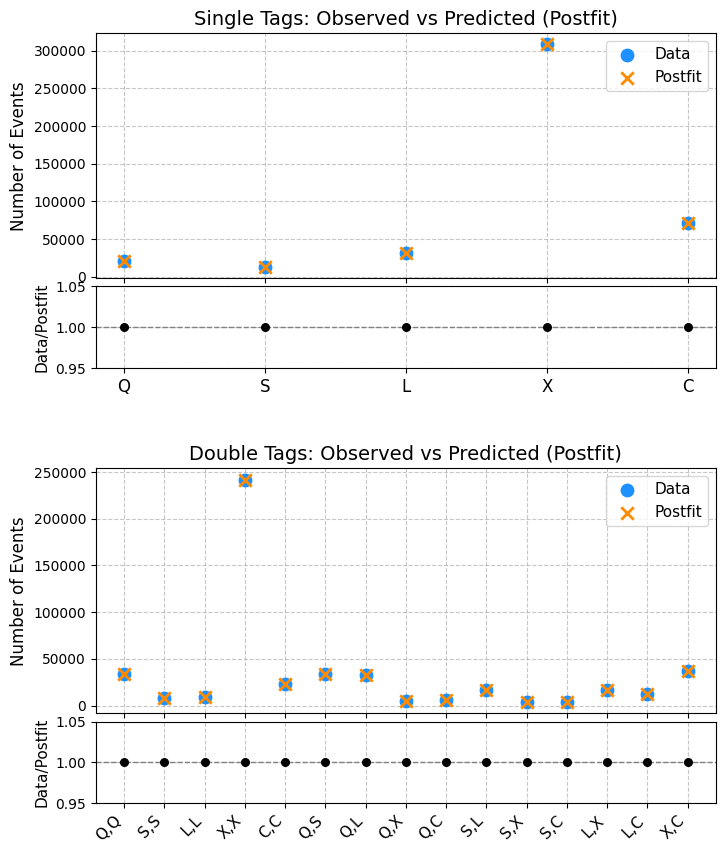

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Postfit prediction
# -------------------------
predictions = fit.predict(
    m.values["Rb"],
    m.values["eQb"], m.values["eSx"], m.values["eSc"], m.values["eSb"],
    m.values["eLx"], m.values["eLc"], m.values["eLb"], m.values["eCx"],
    m.values["eCc"], m.values["eCb"], m.values["eXx"], m.values["eXc"],
    m.values["eXb"]
)

# 1. Prepare Data for Single Tags
single_tags = list(eventsNumber["single"].keys())
single_obs = np.array([eventsNumber["single"][t] for t in single_tags], dtype=float)
single_pred = np.array([predictions["single"][t] for t in single_tags], dtype=float)

# 2. Prepare Data for Double Tags
double_tags = list(eventsNumber["double"].keys())
double_tags_str = [f"{t[0]},{t[1]}" for t in double_tags]
double_obs = np.array([eventsNumber["double"][t] for t in double_tags], dtype=float)
double_pred = np.array([predictions["double"][t] for t in double_tags], dtype=float)

# Ratios: Observed / Predicted
single_ratio = np.divide(
    single_obs, single_pred,
    out=np.full_like(single_obs, np.nan),
    where=single_pred != 0
)
double_ratio = np.divide(
    double_obs, double_pred,
    out=np.full_like(double_obs, np.nan),
    where=double_pred != 0
)

# 3. Create figure with ratio subplots
fig = plt.figure(figsize=(8, 10))

# Outer grid: spacing between top and bottom blocks
outer = fig.add_gridspec(2, 1, hspace=0.30)

# Top block: single tags
gs_top = outer[0].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
ax1 = fig.add_subplot(gs_top[0])
ax1r = fig.add_subplot(gs_top[1], sharex=ax1)

# Bottom block: double tags
gs_bot = outer[1].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
ax2 = fig.add_subplot(gs_bot[0])
ax2r = fig.add_subplot(gs_bot[1], sharex=ax2)

# -------------------------
# Single Tags main plot
# -------------------------
x1 = np.arange(len(single_tags))

ax1.scatter(x1, single_obs, color='dodgerblue', label='Data', marker='o', s=80, zorder=3)
ax1.scatter(x1, single_pred, color='darkorange', label='Postfit', marker='x', s=80, linewidths=2, zorder=3)

ax1.set_ylabel('Number of Events', fontsize=12)
ax1.set_title('Single Tags: Observed vs Predicted (Postfit)', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)
ax1.tick_params(axis='x', labelbottom=False)

# Single ratio plot
ax1r.axhline(1.0, color='grey', linestyle='--', linewidth=1)
ax1r.scatter(x1, single_ratio, color='black', marker='o', s=30, zorder=3)
ax1r.set_ylabel('Data/Postfit', fontsize=11)
ax1r.set_xticks(x1)
ax1r.set_xticklabels(single_tags, fontsize=12)
ax1r.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)
ax1r.set_ylim(0.95, 1.05)

# -------------------------
# Double Tags main plot
# -------------------------
x2 = np.arange(len(double_tags))

ax2.scatter(x2, double_obs, color='dodgerblue', label='Data', marker='o', s=80, zorder=3)
ax2.scatter(x2, double_pred, color='darkorange', label='Postfit', marker='x', s=80, linewidths=2, zorder=3)

ax2.set_ylabel('Number of Events', fontsize=12)
ax2.set_title('Double Tags: Observed vs Predicted (Postfit)', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)
ax2.tick_params(axis='x', labelbottom=False)

# Double ratio plot
ax2r.axhline(1.0, color='grey', linestyle='--', linewidth=1)
ax2r.scatter(x2, double_ratio, color='black', marker='o', s=30, zorder=3)
ax2r.set_ylabel('Data/Postfit', fontsize=11)
ax2r.set_xticks(x2)
ax2r.set_xticklabels(double_tags_str, rotation=45, ha='right', fontsize=11)
ax2r.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)
ax2r.set_ylim(0.95, 1.05)

plt.show()